# Cross-Season Satellite Image Matching Demo
This notebook demonstrates the capabilities of the deep-learning-based image matching algorithm. 

Classical algorithms (like SIFT or ORB) often fail on cross-season satellite imagery because the local pixel colors change drastically (e.g., green fields turning into white snow). To solve this, presented algorithm utilizes **LoFTR**, a Transformer-based feature extractor that understands the global context of the image, paired with **RANSAC** geometric verification to filter out false positives.

In [1]:
import os
import cv2
import json
import torch
import numpy as np
import pandas as pd
import kornia as K
import matplotlib.pyplot as plt
from kornia_moons.viz import draw_LAF_matches

from algorithm import FeatureMatcher
from inference import match_image_pair, run_batch_evaluation

### 1. Initializing the Matching Algorithm

In [2]:
matcher = FeatureMatcher()

### 2. Single Pair Visual & Quantitative Demonstration

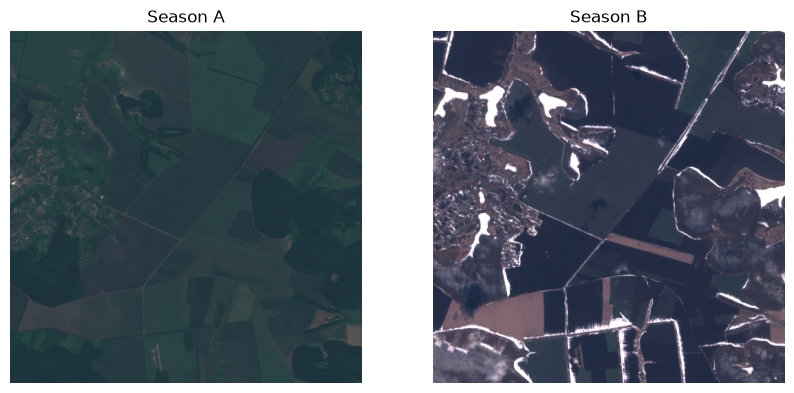

In [3]:
path_img1 = "image_matching_dataset/images/T36UYA_5_A.png" 
path_img2 = "image_matching_dataset/images/T36UYA_5_B.png"

img1 = cv2.cvtColor(cv2.imread(path_img1), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(path_img2), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img1)
axes[0].set_title("Season A")
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].set_title("Season B")
axes[1].axis('off')
plt.show()

================ Single Pair Inference Metrics ================
Raw Keypoint Matches Detected : 289
RANSAC Inliers Retained      : 279
Inlier Match Ratio (Score)   : 96.54%


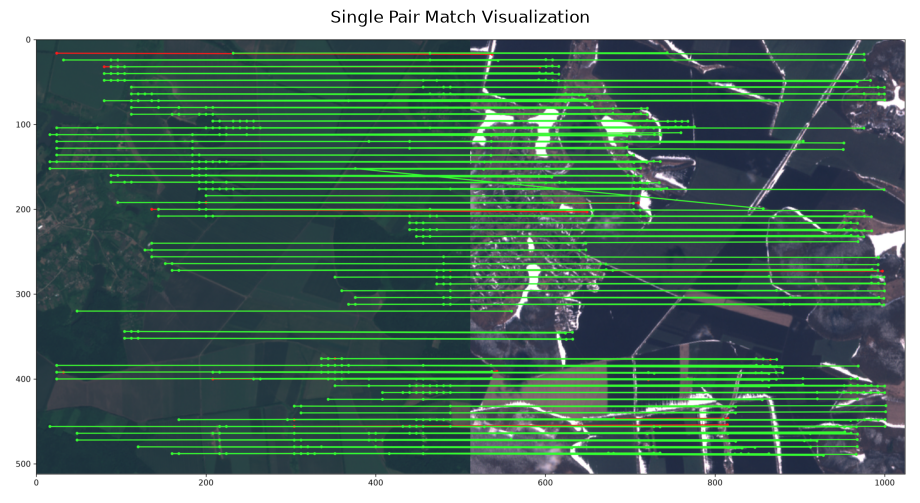

In [4]:
result = match_image_pair(
    matcher=matcher,
    img1_path=path_img1,
    img2_path=path_img2,
    out_path="demo_output/single_pair_match.png"
)

print("================ Single Pair Inference Metrics ================")
print(f"Raw Keypoint Matches Detected : {result['num_raw_matches']}")
print(f"RANSAC Inliers Retained      : {result['num_inliers']}")
print(f"Inlier Match Ratio (Score)   : {result['inlier_ratio']:.2%}")
print("===============================================================")


plt.figure(figsize=(14, 6))
plt.imshow(plt.imread("demo_output/single_pair_match.png"))
plt.axis("off")
plt.title("Single Pair Match Visualization")
plt.show()

### 3. Full Dataset Batch Inference

In [5]:
dataset_dir = "image_matching_dataset"
csv_path = "image_matching_dataset/dataset_labels.csv"

# Execute batch inference across all image pairs via inference.py
batch_df = run_batch_evaluation(
    matcher=matcher,
    csv_path=csv_path,
    dataset_dir=dataset_dir,
    out_dir="demo_output/batch_results",
    min_inlier_thresh=15 # Threshold for success criterion
)

# Display first few results
batch_df.head(10)

,patch_id,image_A_path,image_B_path,raw_matches,inliers,inlier_ratio,success
0,T36UYA_0,images/T36UYA_0_A.png,images/T36UYA_0_B.png,81,77,0.950617,True
1,T36UYA_1,images/T36UYA_1_A.png,images/T36UYA_1_B.png,394,371,0.941624,True
2,T36UYA_2,images/T36UYA_2_A.png,images/T36UYA_2_B.png,1178,1115,0.946520,True
3,T36UYA_3,images/T36UYA_3_A.png,images/T36UYA_3_B.png,141,129,0.914894,True
4,T36UYA_4,images/T36UYA_4_A.png,images/T36UYA_4_B.png,75,70,0.933333,True
5,T36UYA_5,images/T36UYA_5_A.png,images/T36UYA_5_B.png,289,279,0.965398,True
6,T36UYA_6,images/T36UYA_6_A.png,images/T36UYA_6_B.png,648,596,0.919753,True
7,T36UYA_7,images/T36UYA_7_A.png,images/T36UYA_7_B.png,365,341,0.934247,True
8,T36UYA_8,images/T36UYA_8_A.png,images/T36UYA_8_B.png,129,121,0.937984,True
9,T36UYA_9,images/T36UYA_9_A.png,images/T36UYA_9_B.png,163,158,0.969325,True


### 4. Evaluation Metrics & Visual Distributions

================ QUANTITATIVE METRICS REPORT ================
Total Evaluated Pairs       : 32
Mean Inliers per Pair       : 480.94
Mean Inlier Ratio           : 95.28%
Success Rate (>=15 Inliers) : 100.00%


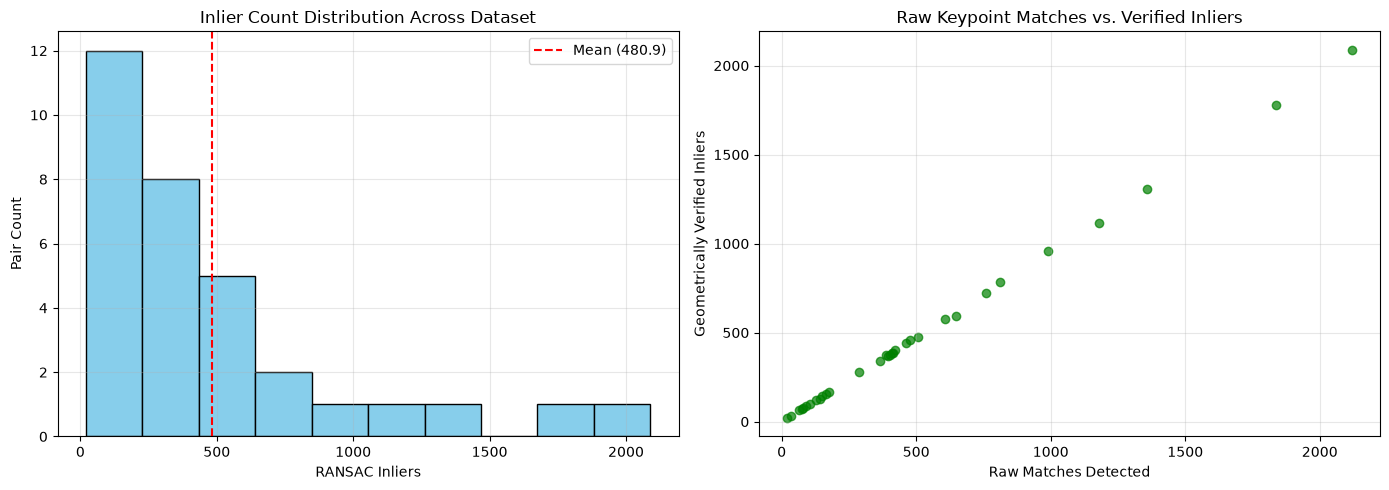

In [6]:
mean_inliers = batch_df['inliers'].mean()
mean_ratio = batch_df['inlier_ratio'].mean()
success_rate = batch_df['success'].mean() * 100.0

print("================ QUANTITATIVE METRICS REPORT ================")
print(f"Total Evaluated Pairs       : {len(batch_df)}")
print(f"Mean Inliers per Pair       : {mean_inliers:.2f}")
print(f"Mean Inlier Ratio           : {mean_ratio:.2%}")
print(f"Success Rate (>=15 Inliers) : {success_rate:.2f}%")
print("=============================================================")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(batch_df['inliers'], bins=10, color='skyblue', edgecolor='black')
axes[0].axvline(mean_inliers, color='red', linestyle='--', label=f'Mean ({mean_inliers:.1f})')
axes[0].set_title("Inlier Count Distribution Across Dataset")
axes[0].set_xlabel("RANSAC Inliers")
axes[0].set_ylabel("Pair Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(batch_df['raw_matches'], batch_df['inliers'], color='green', alpha=0.7)
axes[1].set_title("Raw Keypoint Matches vs. Verified Inliers")
axes[1].set_xlabel("Raw Matches Detected")
axes[1].set_ylabel("Geometrically Verified Inliers")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Qualitative Analysis

In [22]:
# Identify best and worst pairs
best_row = batch_df.loc[batch_df['inliers'].idxmax()]
worst_row = batch_df.loc[batch_df['inliers'].idxmin()]

best_img_path = f"demo_output/batch_results/{best_row['patch_id']}_match.png"
worst_img_path = f"demo_output/batch_results/{worst_row['patch_id']}_match.png"

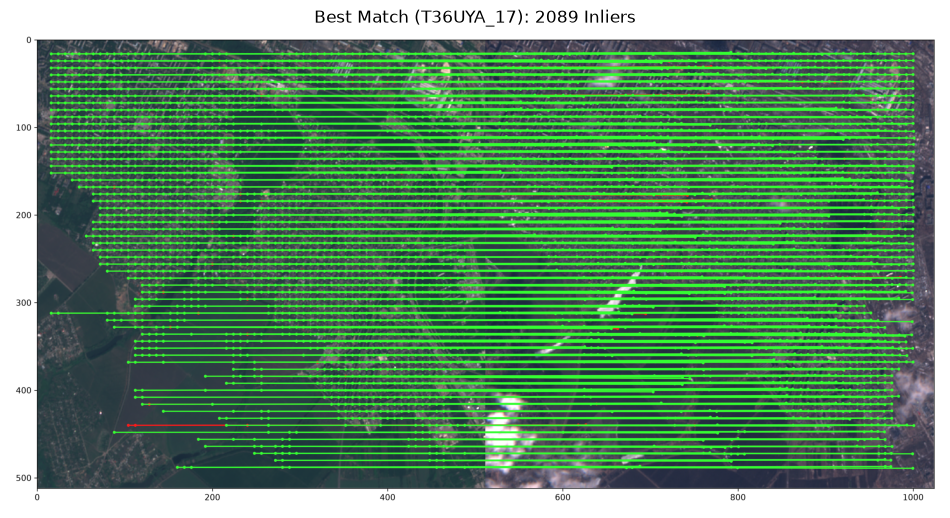

In [29]:
plt.figure(figsize=(12, 10))
plt.imshow(plt.imread(best_img_path))
plt.axis("off")
plt.title(f"Best Match ({best_row['patch_id']}): {best_row['inliers']} Inliers")
plt.show()

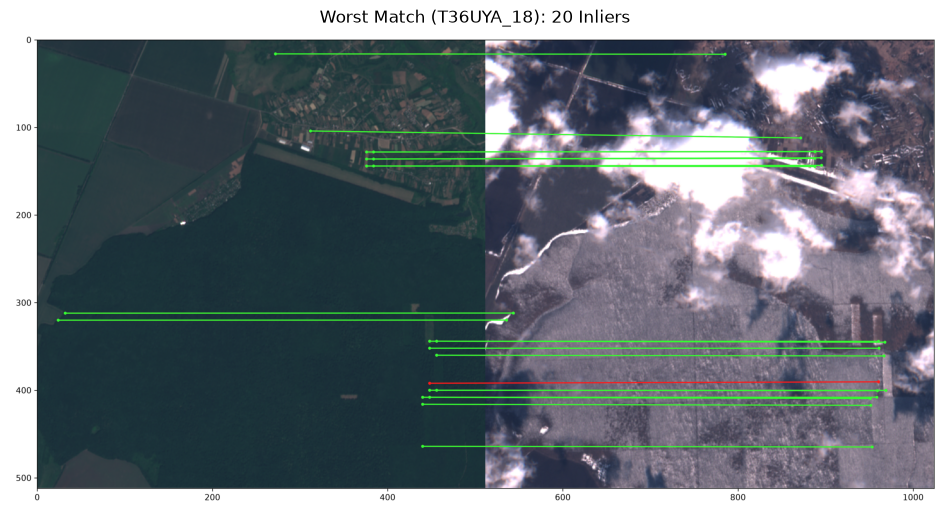

In [30]:
plt.figure(figsize=(12, 10))
plt.imshow(plt.imread(worst_img_path))
plt.axis("off")
plt.title(f"Worst Match ({worst_row['patch_id']}): {worst_row['inliers']} Inliers")
plt.show()